In [4]:
# TP6.1 — Demand exploration and visualization (Bike Sharing Demand)

#Goal: load hourly demand, check quality, visualize patterns, and quantify temporal dependencies.


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
# Change this root folder if your project is elsewhere
ROOT = r"D:\UFR STGI\second Semester\Machine Learning\cours_ia"

def find_file(root, filename):
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    return None

csv_path = find_file(ROOT, "train.csv")

print("Notebook folder:", os.getcwd())
print("Search root    :", ROOT)
print("Found train.csv:", csv_path)

if csv_path is None:
    raise FileNotFoundError(
        f"train.csv was NOT found under:\n{ROOT}\n"
        "Put train.csv inside this folder (or change ROOT to the folder where it is)."
    )


Notebook folder: D:\UFR STGI\second Semester\Machine Learning\cours_ia\TpsAHMED\IA prédictive AHMED\TP6_Series_Temporelles
Search root    : D:\UFR STGI\second Semester\Machine Learning\cours_ia
Found train.csv: D:\UFR STGI\second Semester\Machine Learning\cours_ia\IA prédictive\TP6_Series_Temporelles\train.csv


In [13]:
df = pd.read_csv(csv_path, parse_dates=["datetime"])

serie = df.set_index("datetime")["count"].sort_index()

print("Missing values (raw):", serie.isna().sum())
print("Index type:", type(serie.index))
print("Time span:", serie.index.min(), "->", serie.index.max())
print("Observations:", serie.size)

df.head()


Missing values (raw): 0
Index type: <class 'pandas.DatetimeIndex'>
Time span: 2011-01-01 00:00:00 -> 2012-12-19 23:00:00
Observations: 10886


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [14]:
serie = serie.asfreq("h")  # enforce hourly frequency
print("Missing after asfreq:", serie.isna().sum())

# Forward-fill: assumes demand stays close to last observed value
serie = serie.ffill()
print("Missing after ffill :", serie.isna().sum())

print("Inferred frequency:", serie.index.inferred_freq)


Missing after asfreq: 6370
Missing after ffill : 0
Inferred frequency: h


In [15]:
display(serie.head(24))
display(serie.tail(24))


datetime
2011-01-01 00:00:00     16.0
2011-01-01 01:00:00     40.0
2011-01-01 02:00:00     32.0
2011-01-01 03:00:00     13.0
2011-01-01 04:00:00      1.0
2011-01-01 05:00:00      1.0
2011-01-01 06:00:00      2.0
2011-01-01 07:00:00      3.0
2011-01-01 08:00:00      8.0
2011-01-01 09:00:00     14.0
2011-01-01 10:00:00     36.0
2011-01-01 11:00:00     56.0
2011-01-01 12:00:00     84.0
2011-01-01 13:00:00     94.0
2011-01-01 14:00:00    106.0
2011-01-01 15:00:00    110.0
2011-01-01 16:00:00     93.0
2011-01-01 17:00:00     67.0
2011-01-01 18:00:00     35.0
2011-01-01 19:00:00     37.0
2011-01-01 20:00:00     36.0
2011-01-01 21:00:00     34.0
2011-01-01 22:00:00     28.0
2011-01-01 23:00:00     39.0
Freq: h, Name: count, dtype: float64

datetime
2012-12-19 00:00:00     41.0
2012-12-19 01:00:00     15.0
2012-12-19 02:00:00      3.0
2012-12-19 03:00:00      5.0
2012-12-19 04:00:00      7.0
2012-12-19 05:00:00     31.0
2012-12-19 06:00:00    112.0
2012-12-19 07:00:00    363.0
2012-12-19 08:00:00    678.0
2012-12-19 09:00:00    317.0
2012-12-19 10:00:00    164.0
2012-12-19 11:00:00    200.0
2012-12-19 12:00:00    236.0
2012-12-19 13:00:00    213.0
2012-12-19 14:00:00    218.0
2012-12-19 15:00:00    237.0
2012-12-19 16:00:00    334.0
2012-12-19 17:00:00    562.0
2012-12-19 18:00:00    569.0
2012-12-19 19:00:00    336.0
2012-12-19 20:00:00    241.0
2012-12-19 21:00:00    168.0
2012-12-19 22:00:00    129.0
2012-12-19 23:00:00     88.0
Freq: h, Name: count, dtype: float64

In [16]:
display(serie.describe())
display(serie.resample("D").sum().describe())


count    17256.000000
mean       151.341910
std        155.813437
min          1.000000
25%         50.000000
50%         93.000000
75%        208.000000
max        977.000000
Name: count, dtype: float64

count     719.000000
mean     3632.205841
std      2051.337368
min       608.000000
25%      1728.000000
50%      3357.000000
75%      5128.500000
max      8714.000000
Name: count, dtype: float64

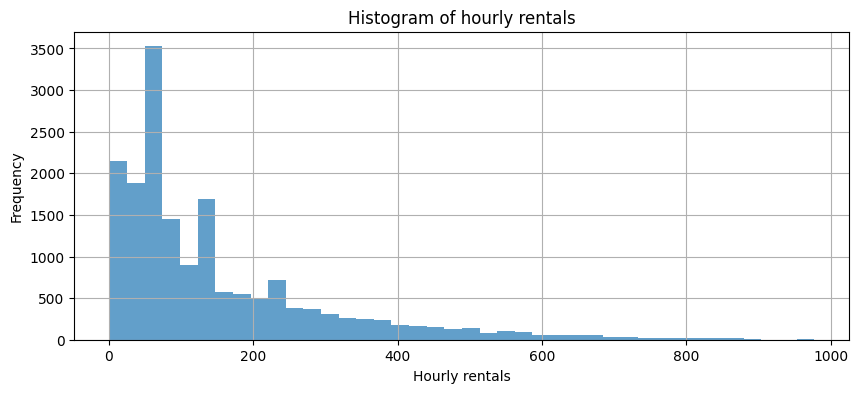

In [17]:
plt.figure(figsize=(10,4))
serie.plot(kind="hist", bins=40, alpha=0.7)
plt.title("Histogram of hourly rentals")
plt.xlabel("Hourly rentals")
plt.grid(True)
plt.show()


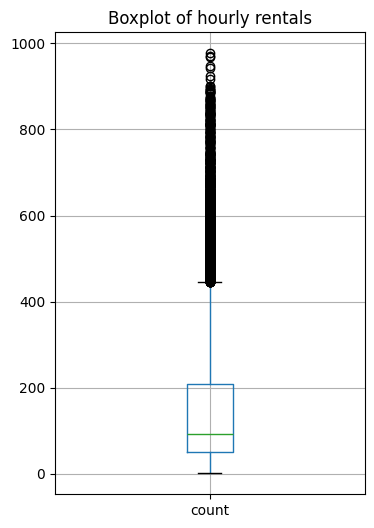

In [18]:
serie.to_frame("count").boxplot(figsize=(4,6))
plt.title("Boxplot of hourly rentals")
plt.grid(True)
plt.show()


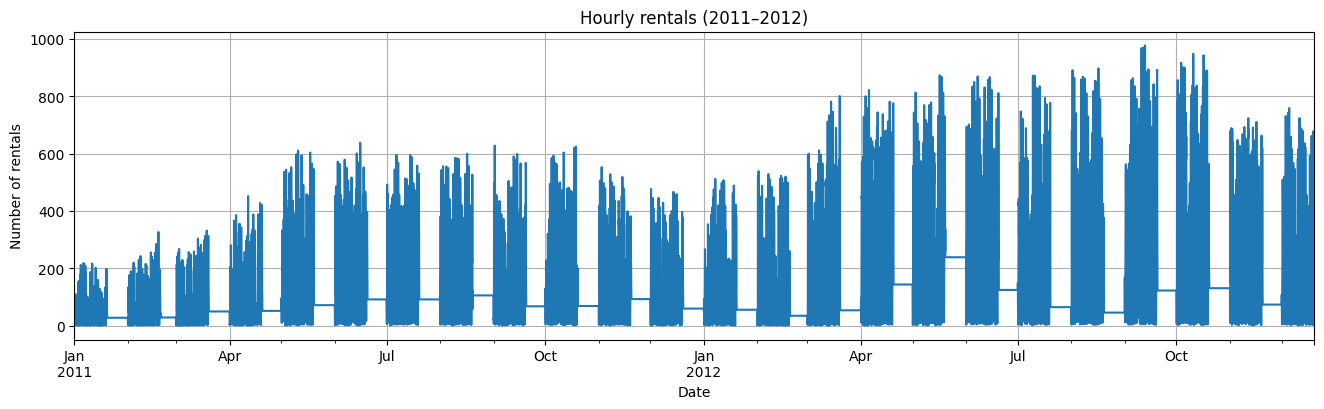

In [19]:
plt.figure(figsize=(16,4))
serie.plot(title="Hourly rentals (2011–2012)")
plt.xlabel("Date")
plt.ylabel("Number of rentals")
plt.grid(True)
plt.show()


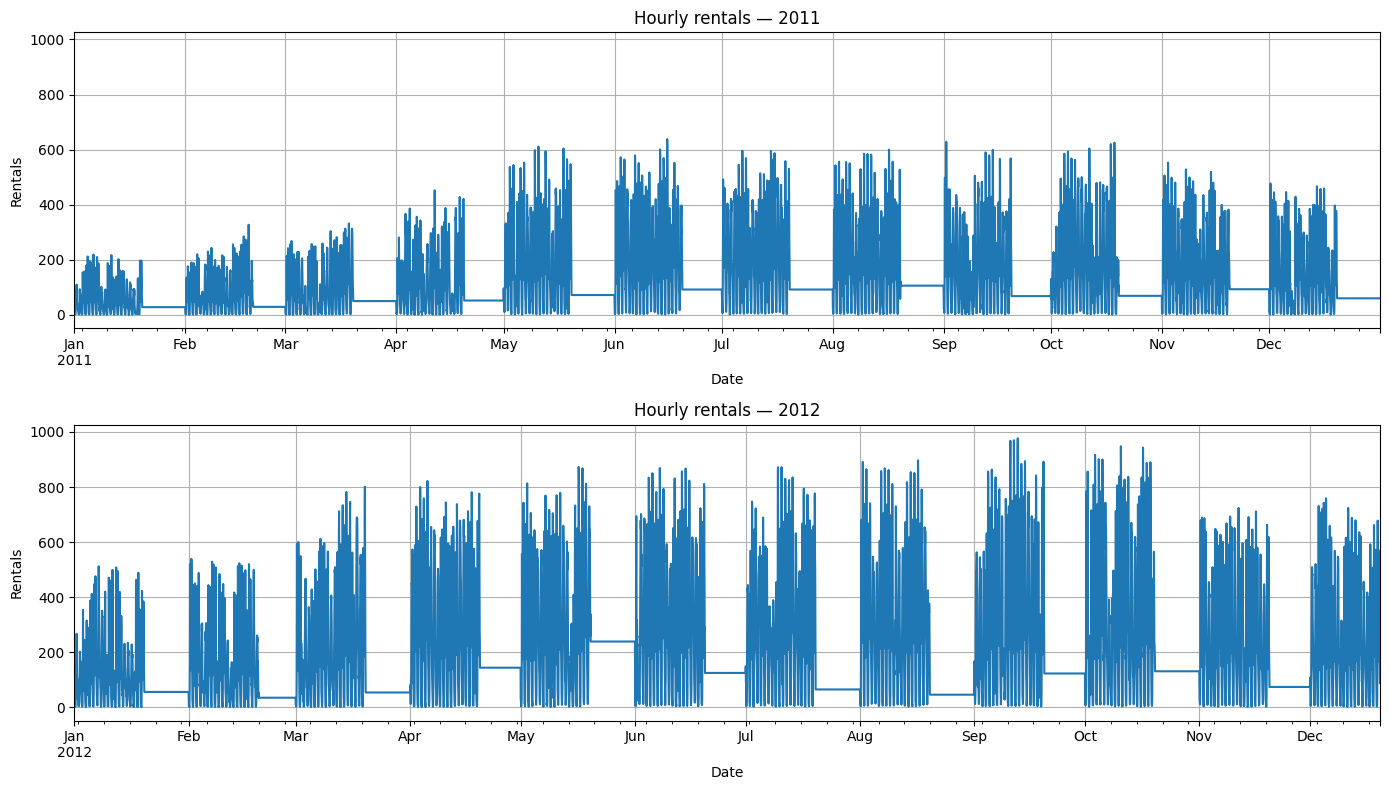

In [30]:
# Compare 2011 vs 2012 (plot each year separately — works even if lengths differ)
years = serie.groupby(serie.index.year)

fig, axes = plt.subplots(len(years), 1, figsize=(14, 8), sharey=True)

# If there is only one year, axes is not an array -> force list
if not isinstance(axes, np.ndarray):
    axes = [axes]

for ax, (yr, s) in zip(axes, years):
    s.plot(ax=ax)
    ax.set_title(f"Hourly rentals — {yr}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Rentals")
    ax.grid(True)

plt.tight_layout()
plt.show()


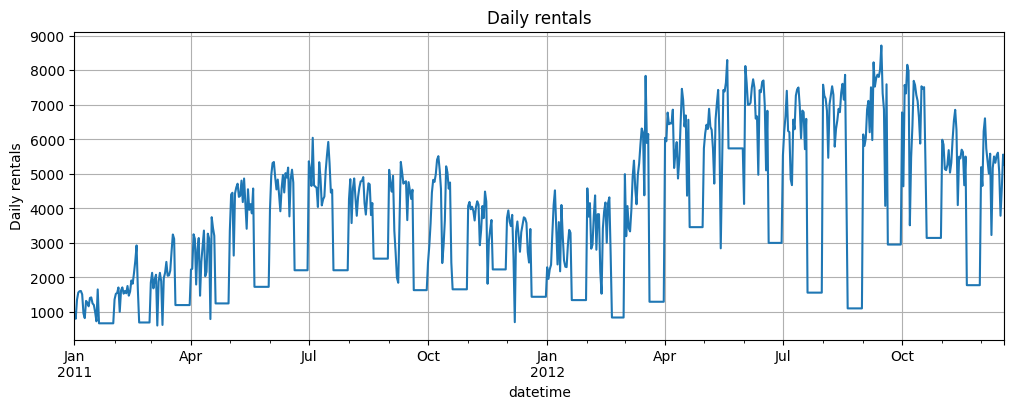

In [22]:
serie.resample("D").sum().plot(figsize=(12,4), title="Daily rentals")
plt.ylabel("Daily rentals")
plt.grid(True)
plt.show()


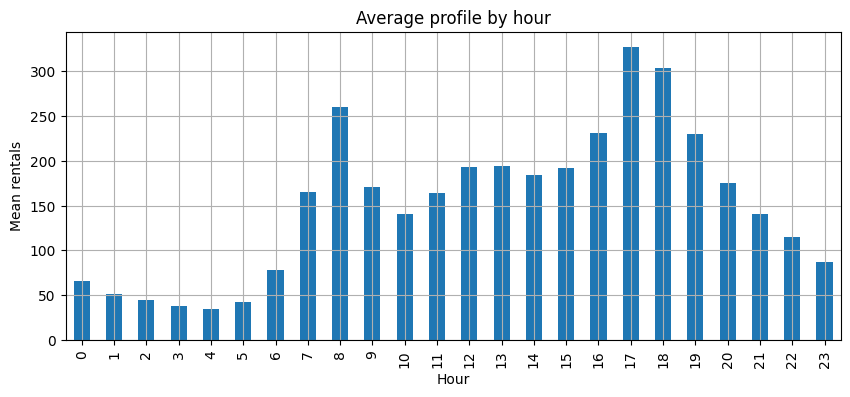

In [23]:
serie.groupby(serie.index.hour).mean().plot(kind="bar", figsize=(10,4))
plt.title("Average profile by hour")
plt.xlabel("Hour")
plt.ylabel("Mean rentals")
plt.grid(True)
plt.show()


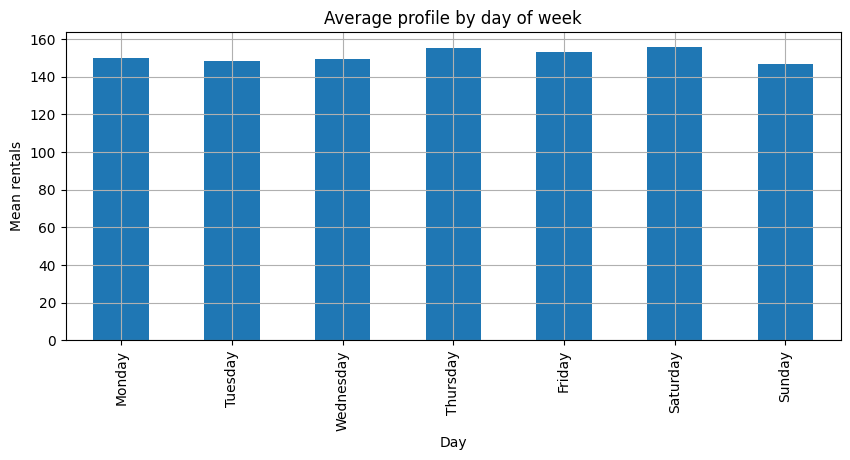

In [24]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

serie.groupby(serie.index.day_name()).mean().reindex(order).plot(kind="bar", figsize=(10,4))
plt.title("Average profile by day of week")
plt.xlabel("Day")
plt.ylabel("Mean rentals")
plt.grid(True)
plt.show()


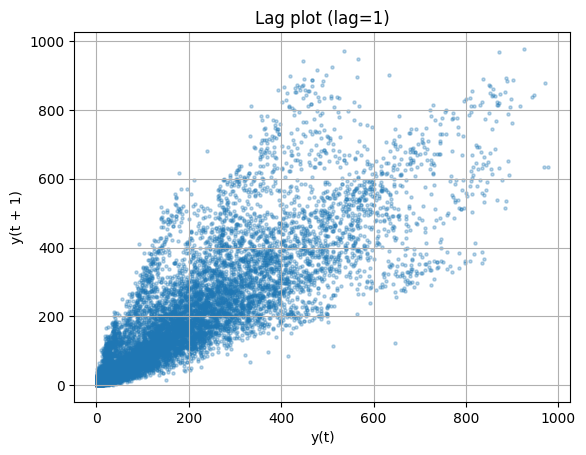

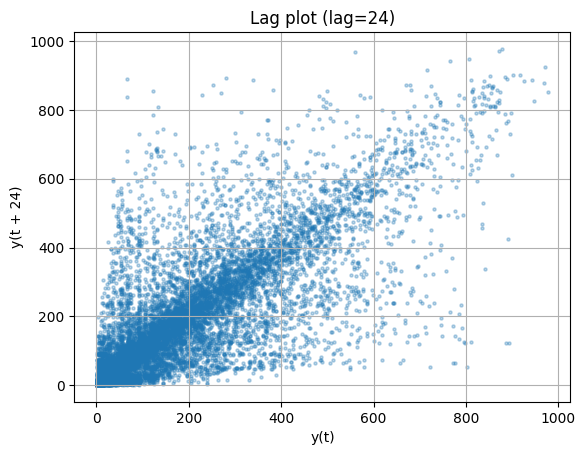

In [25]:
pd.plotting.lag_plot(serie, lag=1, s=5, alpha=0.3)
plt.title("Lag plot (lag=1)")
plt.grid(True)
plt.show()

pd.plotting.lag_plot(serie, lag=24, s=5, alpha=0.3)
plt.title("Lag plot (lag=24)")
plt.grid(True)
plt.show()


In [26]:
import sys, subprocess

try:
    import statsmodels
    print("statsmodels OK:", statsmodels.__version__)
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "statsmodels"])
    import statsmodels
    print("statsmodels installed:", statsmodels.__version__)


statsmodels installed: 0.14.6


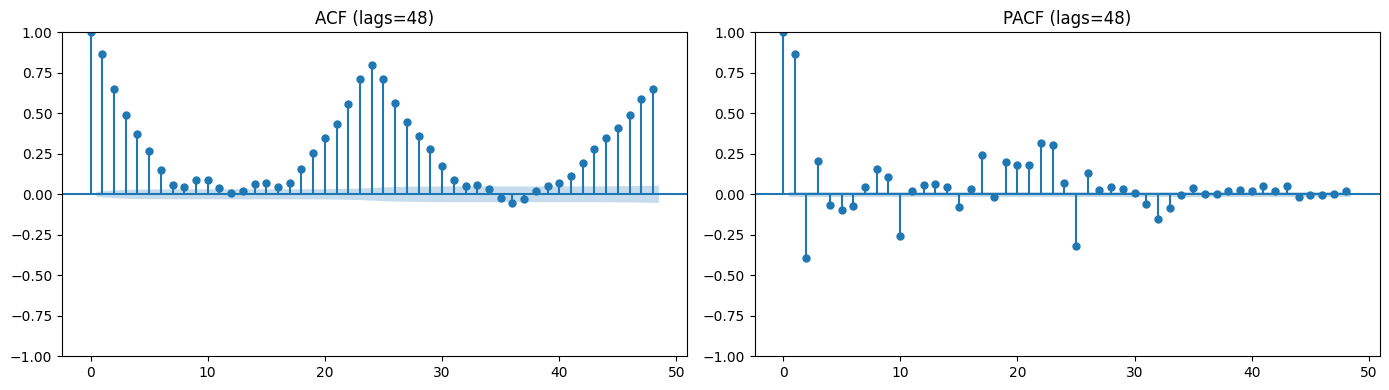

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(serie, lags=48, ax=axes[0])
plot_pacf(serie, lags=48, ax=axes[1], method="ywm")
axes[0].set_title("ACF (lags=48)")
axes[1].set_title("PACF (lags=48)")
plt.tight_layout()
plt.show()


In [28]:
## TP6.1 — Synthesis (5 lines)

# Seasonal patterns observed (daily peaks, weekly cycle, yearly trend):
# Expected peak-hour demand level:
# First suspicion about stationarity (trend/seasonality present?):
# Important lags found (24, 168, etc.):
# Next steps for TP6.2 (decomposition + differencing):


SyntaxError: unmatched ')' (2331590717.py, line 3)